# Estimar distancia a oro

## Contexto
- Pensando que los bordes de los polígonos de potencial de oro no son barreras nítidas (como todo el geología) y que el oro no solo se da _in situ_ donde hay un yacimiento sino que también se da en el aluvión, decido usar un instrumento basado en distancia al potencial de oro (puede ser el polígono de potencial o el aluvión)
- En este cuaderno se expande la lógica usanda en `Efforts/1_estimar_porcentaje_area_potencial_minero` y se expande para calcular la distancia al oro

## Objetivo
- Calcular la distancia de cada municipio a un indicador de potencial de oro:
    - Polígono de potencial
    - Distrito aluvial de oro

## Datos
- [Polígonos de areas con potencial de oro del SGC](https://datos.sgc.gov.co/search?tags=Recursos%2520Minerales)
- [Polígonos del DANE](https://geoportal.dane.gov.co/servicios/descarga-y-metadatos/datos-geoestadisticos/)
- [Distritos aluviales del SGC](https://datos.sgc.gov.co/datasets/9a2140291c4e4dd38754ba673290ce10_0/about)

# Importar paquetes

In [1]:
# Manejo de datos
import geopandas as gpd # Manejo de datos geoespaciales
import pandas as pd # Manejo de datos generales
import datetime # Manejar fechas

# Cálculo numérico
import numpy as np

# Gráficas
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# Utilidades
import time # Medir tiempos de ejecución


# Cargar datos

In [2]:
# Rutas de los archivos
ruta_potencial = '../../Data/2_SGC_Zonas_Potenciales_Metales_Minerales_Preciosos/75f31543-bd1b-43bc-942f-99932ea7eba92020412-1-1srbe6r.4f47.shp'
ruta_distritoAluvial = '../../Data/13_SGC_distritoAluvial/Mapa_Metalog%C3%A9nico_de_Colombia_2020%3A_Distrito_Aluvial.shp'
ruta_municipios = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_MPIO_GRAFICO.shp'
ruta_departamentos = '../../Data/3_DANE_Departamentos_Municipios/ADMINISTRATIVO/MGN_ADM_DPTO_POLITICO.shp'

In [3]:
# Cargar archivos
gdf_potencial = gpd.read_file(ruta_potencial)
gdf_distritosAluviales = gpd.read_file(ruta_distritoAluvial)
gdf_municipios = gpd.read_file(ruta_municipios)
gdf_departamentos = gpd.read_file(ruta_departamentos)

In [4]:
# Explorar datos
display(gdf_potencial.head(2))
display(gdf_distritosAluviales.head(2))
display(gdf_municipios.head(2))

,FID,OBJECTID,IDZPI,NOMBRE,GR_MINERAL,SUBGRUPO_M,ELEM_PRINC,ANOMALIAS,DESC_TEMAT,DESC_GEOGR,...,CAL_ANOM,CAL_FGRA,CAL_FMAG,SUM_POND,CALIFICA,SHAPE_AREA,SHAPE_LEN,Shape__Are,Shape__Len,geometry
0,1,1,P110_01,Vetas 1,METALES Y MINERALES PRECIOSOS,MINERALES DEL ORO,"Au, Ag","Vetas y California, Macizo de Santander 1, Mac...","MINERALIZACION, MINERALES PRECIOSOS, DISTRITO,...","SURATA, CORDILLERA ORIENTAL, SANTANDER, PARAMO...",...,3,0,3,22.00,2.70,0.198794,2.31958,2.483724e+09,259905.908661,"POLYGON ((-8119115.336 839477.764, -8118849.05..."
1,2,2,P114_01,Dabeiba 1,METALES Y MINERALES PRECIOSOS,MINERALES DEL ORO,"Zn, Au-Ag",Dabeiba-Monos,"ORO, PLATA, METALES PRECIOSOS","ENCALICHADA, MONOS, DABEIBA, RIO URAMITA, FILO...",...,1,0,-1,1.24,0.85,0.008625,0.34832,1.076837e+08,38940.994084,"POLYGON ((-8476228.613 779193.446, -8476124.77..."


,FID,OBJECTID,No_Distrit,DMM_NOMB_D,METAL,Shape_Leng,CODE_2020,Shape__Len,geometry
0,1,1,14,ALUVIÓN AURÍFERO RÍO NECHÍ,Au,0.952289,0124,1.066156e+05,"LINESTRING (-8323291.301 904259.877, -8323052...."
1,2,2,8,ALUVIÓN AURÍFERO RÍO CAUCA,Au,14.227590,0124,1.591542e+06,"MULTILINESTRING ((-8417057.437 640766.422, -84..."


,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."


In [5]:
# Mostrar información de los datos disponibles
print("\n"+"***"*20+"Zonas metales preciosos")
display(gdf_potencial.info())

print("\n"+"***"*20+"Distritos aluviales")
display(gdf_potencial.info())

print("\n"+"***"*20+"Municipios")
display(gdf_municipios.info())


************************************************************Zonas metales preciosos
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         115 non-null    int32   
 1   OBJECTID    115 non-null    int32   
 2   IDZPI       115 non-null    object  
 3   NOMBRE      115 non-null    object  
 4   GR_MINERAL  115 non-null    object  
 5   SUBGRUPO_M  115 non-null    object  
 6   ELEM_PRINC  115 non-null    object  
 7   ANOMALIAS   98 non-null     object  
 8   DESC_TEMAT  98 non-null     object  
 9   DESC_GEOGR  98 non-null     object  
 10  NUM_ANOM    115 non-null    object  
 11  POTENCIAL   115 non-null    object  
 12  T_MINERIA   86 non-null     object  
 13  RESTRICCIO  90 non-null     object  
 14  RAN_GRAV    115 non-null    object  
 15  RAN_MAGN    72 non-null     object  
 16  CAL_ANOM    115 non-null    int32   
 17 

None


************************************************************Distritos aluviales
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         115 non-null    int32   
 1   OBJECTID    115 non-null    int32   
 2   IDZPI       115 non-null    object  
 3   NOMBRE      115 non-null    object  
 4   GR_MINERAL  115 non-null    object  
 5   SUBGRUPO_M  115 non-null    object  
 6   ELEM_PRINC  115 non-null    object  
 7   ANOMALIAS   98 non-null     object  
 8   DESC_TEMAT  98 non-null     object  
 9   DESC_GEOGR  98 non-null     object  
 10  NUM_ANOM    115 non-null    object  
 11  POTENCIAL   115 non-null    object  
 12  T_MINERIA   86 non-null     object  
 13  RESTRICCIO  90 non-null     object  
 14  RAN_GRAV    115 non-null    object  
 15  RAN_MAGN    72 non-null     object  
 16  CAL_ANOM    115 non-null    int32   
 17  CAL

None


************************************************************Municipios
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   dpto_ccdgo  1122 non-null   object  
 1   mpio_ccdgo  1122 non-null   object  
 2   mpio_cdpmp  1122 non-null   object  
 3   dpto_cnmbr  1122 non-null   object  
 4   mpio_cnmbr  1122 non-null   object  
 5   mpio_crslc  1122 non-null   object  
 6   mpio_tipo   1122 non-null   object  
 7   mpio_narea  1122 non-null   float64 
 8   mpio_nano   1122 non-null   int32   
 9   shape_Leng  1122 non-null   float64 
 10  shape_Area  1122 non-null   float64 
 11  geometry    1122 non-null   geometry
dtypes: float64(3), geometry(1), int32(1), object(7)
memory usage: 100.9+ KB


None

# Pre-Procesamiento

## Asegurarse que los datos estén en el mismo Sistema de Coordenadas
Para que el cálculo de áreas tenga sentido, ambas capas deben estar en un sistema de coordenadas apropiado para medir areas en Colombia.

Se va a usar MAGNA-SIRGAS (EPSG:3116), que es el sistema geodésico oficial de Colombia.
- Lo usa el Instituto Geográfico Agustín Codazzi (IGAC)
- Es el estándar en cartografía oficial del país

In [6]:
# Explorar Coordinate Reference System (CRS)
print('*'*20 + '\nCRS Original')
print('Potencial:', gdf_potencial.crs)
print('Distritos aluviales:', gdf_distritosAluviales.crs)
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)

# Reproyectar ambas capas a un CRS apropiado para Colombia
# Se va a proyectar en MAGNA-SIRGAS que es el estándar en Colombia
crs_area = "EPSG:3116"
gdf_potencial = gdf_potencial.to_crs(crs_area)
gdf_distritosAluviales = gdf_distritosAluviales.to_crs(crs_area)
gdf_municipios = gdf_municipios.to_crs(crs_area)
gdf_departamentos = gdf_departamentos.to_crs(crs_area)

# Mostrar nuevos sistema de coordenadas
print('*'*20 + '\nNuevo CRS')
print('Potencial:', gdf_potencial.crs)
print('Distritos aluviales:', gdf_distritosAluviales.crs)
print('Municipios:', gdf_municipios.crs)
print('Departamentos:', gdf_departamentos.crs)

********************
CRS Original
Potencial: EPSG:3857
Distritos aluviales: EPSG:3857
Municipios: EPSG:4326
Departamentos: EPSG:4326
********************
Nuevo CRS
Potencial: EPSG:3116
Distritos aluviales: EPSG:3116
Municipios: EPSG:3116
Departamentos: EPSG:3116


## Revisar geometrías invalidas

In [7]:
print('*'*20 + '\nPotencial')
print(f"\nVálidas:\n{gdf_potencial.is_valid.value_counts()}")
print(f"\nVacías: {gdf_potencial.is_empty.sum()}")
print(f"Totales: {gdf_potencial.shape[0]}")

print('*'*20 + '\nDistritos aluviales')
print(f"\nVálidas:\n{gdf_distritosAluviales.is_valid.value_counts()}")
print(f"\nVacías: {gdf_distritosAluviales.is_empty.sum()}")
print(f"Totales: {gdf_distritosAluviales.shape[0]}")

print('\n'+'*'*20 + '\nMunicipios')
print(f"\nVálidas:\n{gdf_municipios.is_valid.value_counts()}")
print(f"\nVacías: {gdf_municipios.is_empty.sum()}")
print(f"Totales: {gdf_municipios.shape[0]}")

print('\n'+'*'*20 + '\nDepartamentos')
print(f"\nVálidas:\n{gdf_departamentos.is_valid.value_counts()}")
print(f"\nVacías: {gdf_departamentos.is_empty.sum()}")
print(f"Totales: {gdf_departamentos.shape[0]}")

********************
Potencial

Válidas:
True    115
Name: count, dtype: int64

Vacías: 0
Totales: 115
********************
Distritos aluviales

Válidas:
True    31
Name: count, dtype: int64

Vacías: 0
Totales: 31

********************
Municipios

Válidas:
True    1122
Name: count, dtype: int64

Vacías: 0
Totales: 1122

********************
Departamentos

Válidas:
True    33
Name: count, dtype: int64

Vacías: 0
Totales: 33


## Organizar categorías de minerales

### Poligonos de potencial

In [8]:
# Los subgrupos y minerales de cada polígono no están completamente ordenados
display(gdf_potencial['ELEM_PRINC'].unique())
display(gdf_potencial['SUBGRUPO_M'].unique())

array(['Au, Ag', 'Zn, Au-Ag', 'Au-Ag', 'Au', 'Au-MGP', 'Au, Cu, Ag',
       'MGP', 'Au-Cu, Au, Cr-Ni, Ag', 'Cr, Pb-Zn, Au, Au-Ag',
       'Be, Na/K, Li/Na, Na, K, Li, Pb, K/Na', 'Na/K', 'Au, Au-Ag, Ag',
       'Au, Cu', 'Na/K, Li/Na, Na, K, Li, Na/Li, Ba',
       'Zn, Ag, Au-Ag, Sr, Mo, Pb, Au, Sb, Cu, Ba', 'Au, Ag-Au, Ag',
       'Au-Ag, Ag', 'Pb, Zn, Au, Cu', 'As, Au, Au-Ag',
       'Pb, Zn, Au, Au-Ag', 'As, Au-Ag', 'Qz, Au',
       'Au-MGP, Au, Ag, MPG-Au', 'Pb, Au, Ag', 'Au-MGP, Au, Au-Ag, MGP',
       'Ag', 'As, Au, Au-Ag, Ag', 'Cr-Ni, Au-Ag', 'Au, Au-Ag',
       'Cu, Au, Au-Ag, Ag', 'Pt, Au, Au-Ag, Ag', 'Au-MGP, Au',
       'Au-MGP, Au, Ag', 'MGP-Au, Au-MGP', 'Au-Cu, Au-Ag, Ag',
       'Sb, Au-Cu, Au, Au-Ag', 'Au, Pt, Au-Ag', 'Na/Li'], dtype=object)

array(['MINERALES DEL ORO', 'MINERALES DEL PLATINO',
       'MINERALES DE PLATA, MINERALES DEL ORO', 'MINERALES PRECIOSOS',
       'MINERALES DELORO, MINERALES DEL ORO', 'MIENRALES DEL ORO',
       'MINERALES PRECIOSOS, MINERALES DELORO, MINERALES DEL ORO',
       'MINERALES DEL PLATINO, MINERALES DEL ORO', 'MINERALES DE PLATA'],
      dtype=object)

In [9]:
def clasificar_mineral(elem):
    """
    Clasifica ELEM_PRINC en categorías geológico-económicas amplias.
    """
    if pd.isna(elem):
        return "Otros"
    
    s = str(elem).upper().strip()
    
    # Normalizar separadores
    s = s.replace("/", "-").replace(",", "-")
    partes = [x.strip() for x in s.split("-") if x.strip() != ""]
    partes_set = set(partes)
    
    # Tokens relevantes
    tiene_au = "AU" in partes_set
    tiene_ag = "AG" in partes_set
    tiene_cu = "CU" in partes_set
    tiene_pb = "PB" in partes_set
    tiene_zn = "ZN" in partes_set
    tiene_mgp = "MGP" in partes_set
    tiene_pt = "PT" in partes_set
    
    # Platinoides
    if tiene_mgp or tiene_pt:
        return "Platinoides"
    
    # Metales base
    n_base = sum([tiene_cu, tiene_pb, tiene_zn])
    
    # Preciosos
    n_preciosos = sum([tiene_au, tiene_ag])
    
    # Polimetálicos / complejos:
    # mezcla de preciosos con base metals, o combinaciones largas
    if (n_preciosos >= 1 and n_base >= 1) or len(partes_set) >= 4:
        return "Polimetálicos / complejos"
    
    # Metales base
    if n_base >= 1:
        return "Metales base"
    
    # Oro y preciosos
    if tiene_au or tiene_ag:
        return "Oro y preciosos"
    
    return "Otros"

In [10]:
# Aplicar la clasificación
gdf_potencial["categoria_mineral"] = gdf_potencial["ELEM_PRINC"].apply(clasificar_mineral)

print("Categorías minerales asignadas\n")
display(gdf_potencial["categoria_mineral"].value_counts(dropna=False))

Categorías minerales asignadas



categoria_mineral
Oro y preciosos              81
Polimetálicos / complejos    16
Platinoides                  16
Otros                         2
Name: count, dtype: int64

### Distritos aluviales

In [11]:
# 30 de los 31 aluviones son auriferos. El otro es titanifero.
# En los aluviones titaniferos puede haber trazas de oro. En comparación a 
# los aluviones auriferos, la concentración es muy baja
# Voy a calcular la distancia a (I) cualquier aluvión y (II) aluviones auriferos.
# Lo que espero es que la distancia a los aluviones auriferos sea más relevante para
# explicar la producción de oro que la distancia a cualquier aluvión

display(gdf_distritosAluviales['METAL'].unique()) # Revisar los metales asociados

gdf_distritosAluviales['categoria_mineral'] = '' # Columna vacía para informar el tipo de aluvión

filas_Au = gdf_distritosAluviales['METAL'].str.contains('Au')
gdf_distritosAluviales.loc[filas_Au, 'categoria_mineral'] = 'Aluvión Aurífero'

filas_Ti = gdf_distritosAluviales['METAL'].str.contains('Ti')
gdf_distritosAluviales.loc[filas_Ti, 'categoria_mineral'] = 'Aluvión Titanífero'

# Mostrar resultados de la nueva columna
print(f"\n{'*'*20} variable generada")
display(gdf_distritosAluviales.groupby(['categoria_mineral', 'METAL'])['FID'].count().reset_index())

array(['Au', 'Au-Pt', 'Ti'], dtype=object)


******************** variable generada


,categoria_mineral,METAL,FID
0,Aluvión Aurífero,Au,27
1,Aluvión Aurífero,Au-Pt,3
2,Aluvión Titanífero,Ti,1


# Procesamiento

## Calcular distancia a yacimientos de oro

In [12]:
# Crear geometrías unificadas para acelerar el cálculo
geom_potencial_union = gdf_potencial.geometry.union_all()
geom_aluvial_union = gdf_distritosAluviales.geometry.union_all()

In [14]:
# Calcular distancia mínima desde cada municipio

# Para 10 municipios, el cálculo toma 2.5 segundos.
# Como son 1122 poligonos de municipios, el cálculo debe tomar aproximadamente 5 minutos

# Esto calcula distancia entre polígonos. 
# Si un municipio intersecta un polígono de potencial o distrito aluvial, la distancia será 0
gdf_calculo = gdf_municipios.copy()

start_time = time.time() # Medir tiempo
print(f"Inicio: {datetime.datetime.now()}")

gdf_calculo["dist_potencial_m"] = gdf_calculo.geometry.distance(geom_potencial_union)
gdf_calculo["dist_aluvial_m"] = gdf_calculo.geometry.distance(geom_aluvial_union)

gdf_calculo["dist_potencial_km"] = gdf_calculo["dist_potencial_m"] / 1000
gdf_calculo["dist_aluvial_km"] = gdf_calculo["dist_aluvial_m"] / 1000

print("--- %s seconds ---" % (time.time() - start_time)) # Medir tiempo
print(f"Fin: {datetime.datetime.now()}")

Inicio: 2026-04-24 16:00:05.934884
--- 552.2349615097046 seconds ---
Fin: 2026-04-24 16:09:18.169846


In [15]:
# Calcular variable de cercanía (proximidad)
gdf_calculo["proximidad_potencial"] = 1 / (1 + gdf_calculo["dist_potencial_km"])
gdf_calculo["proximidad_aluvial"] = 1 / (1 + gdf_calculo["dist_aluvial_km"])

# Calcular distancia al potencial aurífero o al distrito aluvial más cercano
gdf_calculo["dist_geo_oro_km"] = gdf_calculo[
    ["dist_potencial_km", "dist_aluvial_km"]
].min(axis=1)

gdf_calculo["proximidad_geo_oro"] = 1 / (1 + gdf_calculo["dist_geo_oro_km"])

# Almacenar resultados
# gdf_calculo.to_excel('./gdf_calculo.xlsx')

# Verificación visual

## Mapa Municipios + Contornos de Potencial + Distritos aluviales

### Clasificar los elementos principales de los polígonos según tipos de minería

In [16]:
# Mostrar categorías de los minerales
display(gdf_potencial["categoria_mineral"].value_counts())

categoria_mineral
Oro y preciosos              81
Polimetálicos / complejos    16
Platinoides                  16
Otros                         2
Name: count, dtype: int64

In [17]:
# Definir colores de las categorías
colores_categoria = {
    "Oro y preciosos": "#D4A017",              # dorado
    "Metales base": "#2C7FB8",                 # azul
    "Polimetálicos / complejos": "#7A5195",   # morado
    "Platinoides": "#1B5E20",                  # verde oscuro
    "Otros": "#BDBDBD"                         # gris
}

# Asignar color a cada polígono
gdf_potencial["color_categoria"] = gdf_potencial["categoria_mineral"].map(colores_categoria)

### Mapa

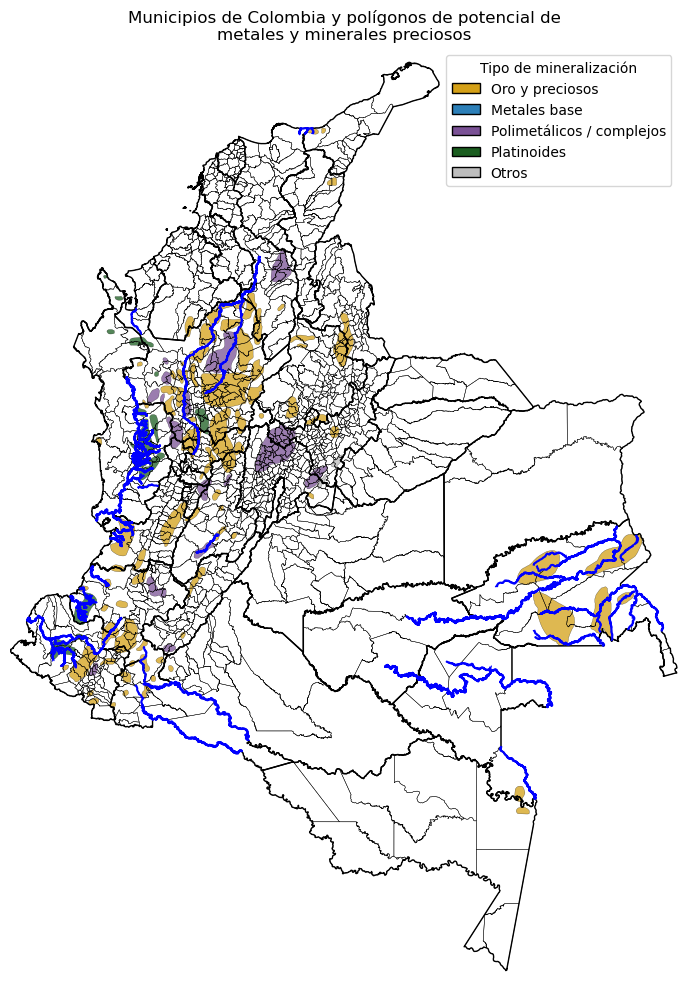

<Figure size 640x480 with 0 Axes>

In [71]:
# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))

# Contornos de municipios y departamentos
gdf_municipios.boundary.plot(ax=ax, linewidth=0.3, color='black')
gdf_departamentos.boundary.plot(ax=ax, linewidth=1, color='black')

# Polígonos de potencial: relleno por categoría
#gdf_potencial.plot(ax=ax, linewidth=0.8, color='pink')
for categoria, color in colores_categoria.items():
    subset = gdf_potencial[gdf_potencial["categoria_mineral"] == categoria]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor="black",
            linewidth=0.2,
            alpha=0.75
        )

# Distritios aluviales
gdf_distritosAluviales.plot(ax=ax,
                           linewidth=1.5,
                           color='blue')
  
# Leyenda manual
handles = [
    Patch(facecolor=color, edgecolor="black", label=cat)
    for cat, color in colores_categoria.items()
]

ax.legend(
    handles=handles,
    title="Tipo de mineralización",
    loc="upper right",
    frameon=True
)


# Ejes
ax.set_xlim([0.45e6, 1.81e6])
ax.set_ylim([0.02e6, 1.9e6])
ax.set_axis_off()

# Presentación de la gráfica
ax.set_title("Municipios de Colombia y polígonos de potencial de\nmetales y minerales preciosos")

# Mostrar y exportar gráfica
plt.show()
plt.tight_layout()
fig.savefig('./outputs/M1_municipios_recursosOro.png', dpi=500)

## Mapa de proximidad al oro

In [41]:
# Unir datos de los municipios con el la distancia al oro
mapa_municipios = gdf_municipios.merge(
    gdf_calculo[["mpio_cdpmp", "proximidad_geo_oro", "dist_geo_oro_km"]],
    on="mpio_cdpmp",
    how="left"
)

# Los municipios que no tiene area con potencial quedan con Nan. Cambiar por cero
# mapa_municipios["pct_municipio_cubierto"] = mapa_municipios["pct_municipio_cubierto"].fillna(0)

# Crear escalas de colores para mostrar los datos de los municipios
# Crear columna donde los ceros sean NaN (para que salgan blancos)
mapa_municipios["plot_map"] = mapa_municipios["proximidad_geo_oro"]

In [63]:
# Definir mapa de colores
base_cmap = plt.cm.Reds
colors = base_cmap(np.linspace(0, 1, 256))
colors[:, -1] = 0.5  # definir alpha manualmente
cmap_alpha = mpl.colors.ListedColormap(colors)
# Gaho esto para poder mostrar el mapa de colores tanto en el mapa como en la barra que pongo a mano

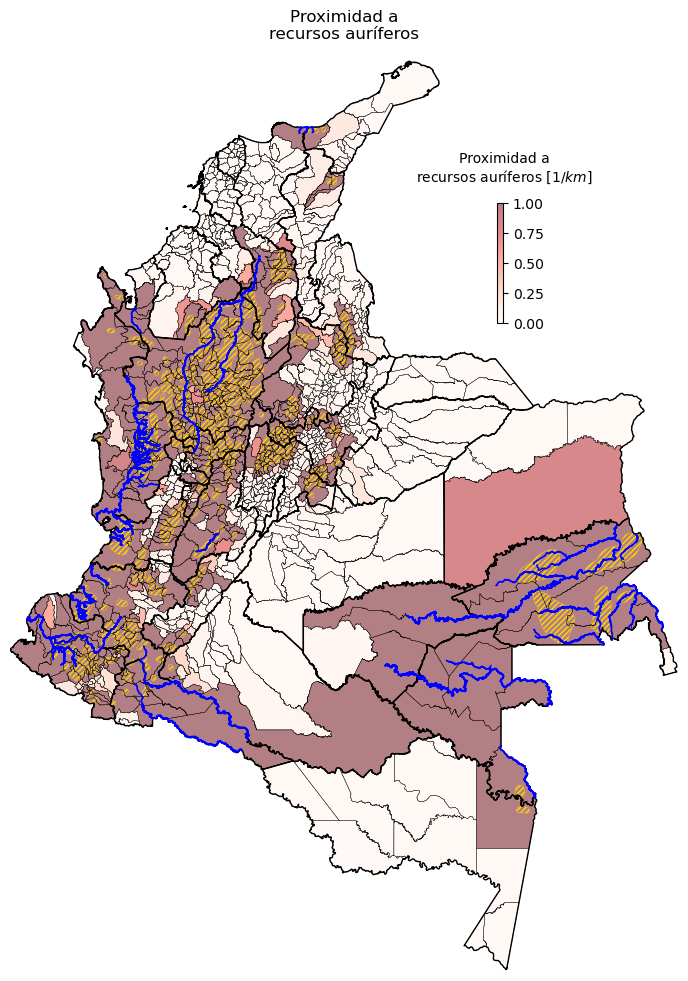

<Figure size 640x480 with 0 Axes>

In [72]:
# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))



# Colorear los municipios según la Proximidad al oro -------------
mapa_municipios.plot(
    column="plot_map",
    cmap=cmap_alpha,
    ax=ax,
    legend=False,
    linewidth=0.1,
    edgecolor="black",
    missing_kwds={ # Pintar Nans como blanco
        "color": "white",
        "label": "Sin potencial"
    }
)

# Contornos departamentos y municipios ------------------------------------------
gdf_departamentos.boundary.plot(ax=ax, linewidth=1, color='black')
gdf_municipios.boundary.plot(ax=ax, linewidth=0.2, color='black')

# Distritios aluviales ----------------------------------------------------
gdf_distritosAluviales.plot(ax=ax,
                           linewidth=1.2,
                           color='blue')

# POlígonos de potencial ----------------------------------------------------
gdf_potencial.plot(
    ax=ax,
    facecolor='none',     # sin relleno sólido
    edgecolor='gold',    # borde negro
    hatch='//////',          # rayas diagonales
    linewidth=0.3,
    alpha=1.0             # opcional, suaviza visualmente
)

# Crear barra de color horizontal ------------------------------------------
# Variables auxiliares para manejar la leyenda de los colores
# Definir normalización de colores
vmin = 0
vmax = mapa_municipios["plot_map"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
#cmap = cmap_alpha

# Ubicar la barra de colores
cax = fig.add_axes([0.6, 0.65, 0.08, 0.1])
cax.set_axis_off()

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_alpha)
sm._A = []  # necesario para matplotlib

cbar = fig.colorbar(
    sm,
    ax=cax,
    orientation="vertical",
    fraction=0.5
)
#cbar.set_ticks([0, 0.25, 0.50, 0.75, 0.100]) # Ticks de la barra de colores

# Incluir anotación como leyenda de la barra de colores
ax.annotate(text="Proximidad a\nrecursos auríferos $[1/km]$",
            xy=(0.74,0.85), xycoords='axes fraction',
            ha='center', va='bottom')


# Ejes -----------------------------------------------------------------------
ax.set_xlim([0.45e6, 1.81e6])
ax.set_ylim([0.02e6, 1.9e6])
ax.set_axis_off()

# Presentación de la gráfica --------------------------------------------------
ax.set_title("Proximidad a\nrecursos auríferos")

# Mostrar y exportar gráfica
plt.show()
plt.tight_layout()
fig.savefig('./outputs/M2_municipios_proximidad_oro.png', dpi=500)

# Exportar datos

In [79]:
# Exportar los datos de porcentaje del area del municipio con potencial minero
print(f"{'*'*20}Estructura de datos ANTES de exportar")
display(gdf_calculo.head(2))

# Dar estructura de panel
columnas_exportar = ['mpio_cdpmp', 'dist_potencial_km', 'dist_aluvial_km', 'dist_geo_oro_km', 'proximidad_geo_oro']
df = gdf_calculo[columnas_exportar].melt(id_vars='mpio_cdpmp',
                                        value_vars=['dist_potencial_km', 'dist_aluvial_km', 'dist_geo_oro_km', 'proximidad_geo_oro'])
print(f"{'*'*20}Estructura de datos PARA de exportar")
display(df.head(2))

# Exportar la distancia a cada recurso aurífero
ruta_salida = './outputs/distancia_proximidad_Au'
df.to_parquet(ruta_salida + '.parquet')
df.to_excel(ruta_salida + '.xlsx')


********************Estructura de datos ANTES de exportar


,dpto_ccdgo,mpio_ccdgo,mpio_cdpmp,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry,dist_potencial_m,dist_aluvial_m,dist_potencial_km,dist_aluvial_km,proximidad_potencial,proximidad_aluvial,dist_geo_oro_km,proximidad_geo_oro
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((844137.069 1177741.6, 844139.799 117...",388.055028,10401.607125,0.388055,10.401607,0.720433,0.087707,0.388055,0.720433
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((845870.684 1149432.09, 845916.181 11...",0.000000,4573.493838,0.000000,4.573494,1.000000,0.179421,0.000000,1.000000


********************Estructura de datos PARA de exportar


,mpio_cdpmp,variable,value
0,05001,dist_potencial_km,0.388055
1,05002,dist_potencial_km,0.000000
